In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import wandb
import torch

In [2]:
from training.train_decoder import download_model_and_config, load_model

training decoder


In [3]:
run_id = 's2gk8uag'

In [4]:
from torch.utils.data import DataLoader
from generators.subseries_converter import EchoStateDataset

model_path, config = download_model_and_config(run_id)
config['esn_store_state'] = True
config['dataset']['val']['num_series'] = 1_000
model = load_model(model_path, config)
model.to('cuda')
dataset = EchoStateDataset(config=config, training=False, num_series=1000)
val_batch_size = 1
dataloader = DataLoader(dataset, batch_size=val_batch_size, shuffle=False)

wandb: Using wandb-core as the SDK backend. Please refer to https://wandb.me/wandb-core for more information.
wandb:   1 of 1 files downloaded.  
/home/wojciech/private/magisterka/TFTS/training/train_decoder.py:34: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file

In [5]:
serieses = []
inputs = []
for x, y in tqdm(dataloader):
    serieses.append(x.cpu().numpy())
    inputs.append(dataloader.dataset.esn.input)

100%|██████████| 1000/1000 [00:21<00:00, 47.40it/s]


In [6]:
serieses = [x.flatten() for x in serieses]

In [7]:
inputs = [np.concatenate(x) for x in inputs]

In [8]:
import numpy as np
import pandas as pd
from scipy.stats import skew, kurtosis

stats = {
    'mean': [],
    'volatility': [],
    'dynamic_range': [],
    'skewness': [],
    'kurtosis': [],
    'autocorr_lag1': [],
    'autocorr_lag10': []
}

for x in inputs:
    x = np.asarray(x).ravel()
    T = len(x)

    # 1. Mean
    mu = np.mean(x)
    stats['mean'].append(mu)

    # 2. Volatility (variance)
    vol = np.var(x, ddof=0)
    stats['volatility'].append(vol)

    # 3. Dynamic range (peak-to-peak)
    dyn_rng = np.ptp(x)
    stats['dynamic_range'].append(dyn_rng)

    # 4. Skewness
    sk = skew(x)
    stats['skewness'].append(sk)

    # 5. Excess Kurtosis
    kurt = kurtosis(x, fisher=True)
    stats['kurtosis'].append(kurt)

    # 6. Short-memory persistence (lag-1 autocorrelation)
    if T > 1:
        ac1 = np.corrcoef(x[:-1], x[1:])[0, 1]
    else:
        ac1 = np.nan
    stats['autocorr_lag1'].append(ac1)

    # 7. Long-memory persistence (lag-10 autocorrelation)
    if T > 10:
        ac10 = np.corrcoef(x[:-10], x[10:])[0, 1]
    else:
        ac10 = np.nan
    stats['autocorr_lag10'].append(ac10)

# Build DataFrame of raw concept values
df_concepts = pd.DataFrame(stats)

In [11]:
quantiles = np.quantile(df_concepts.values, [0.01, 0.99], axis=0)
features = df_concepts.values
high_feature_quantile = features > quantiles[1, :]
low_feature_quantile = features < quantiles[0, :]

In [15]:
high_mean = [x for x, mask in zip(inputs, high_feature_quantile[:, 3]) if mask]
low_mean = [x for x, mask in zip(inputs, low_feature_quantile[:, 3]) if mask]

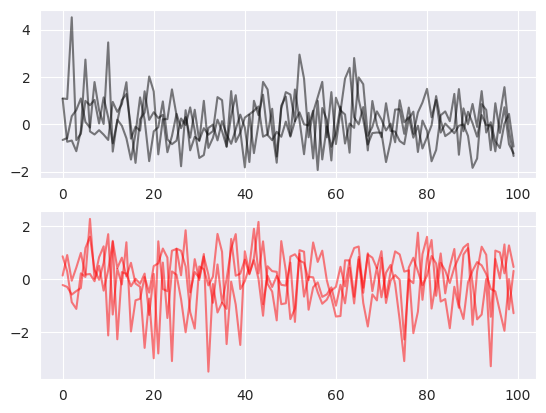

In [16]:
fig, (ax1, ax2) = plt.subplots(2)
for s in high_mean[:3]:
    ax1.plot(s, alpha=0.5, color='black')
for s in low_mean[:3]:
    ax2.plot(s, alpha=0.5, color='red')